<a href="https://colab.research.google.com/github/Koyuki88/Deep-Learning-CompAnalysis/blob/main/Week3_Deliverables_Code_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dependencies installation + data preprocessing

In [ ]:
# All required libraries are imported here at the very top.

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image, ImageOps

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Dependencies loaded successfully!")

Dependencies loaded successfully!


1. LOADING FASHION-MNIST
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original Training set: (60000, 28, 28)
Original Test set: (10000, 28, 28)

2. CREATING 80-20 TRAIN-VALIDATION SPLIT
Training:   (48000, 28, 28) (48,000 samples - 80%)
Validation: (12000, 28, 28) (12,000 samples - 20%)
Test:       (10000, 28, 28) (10,000 samples)

3. SCALING / NORMALIZATION & RESHAPING
x_train: (48000, 28, 28, 1)
x_val:   (12000, 28, 28, 1)
x_test:  (10000, 28, 28, 1)
Pixel range: [0.000, 1.000]


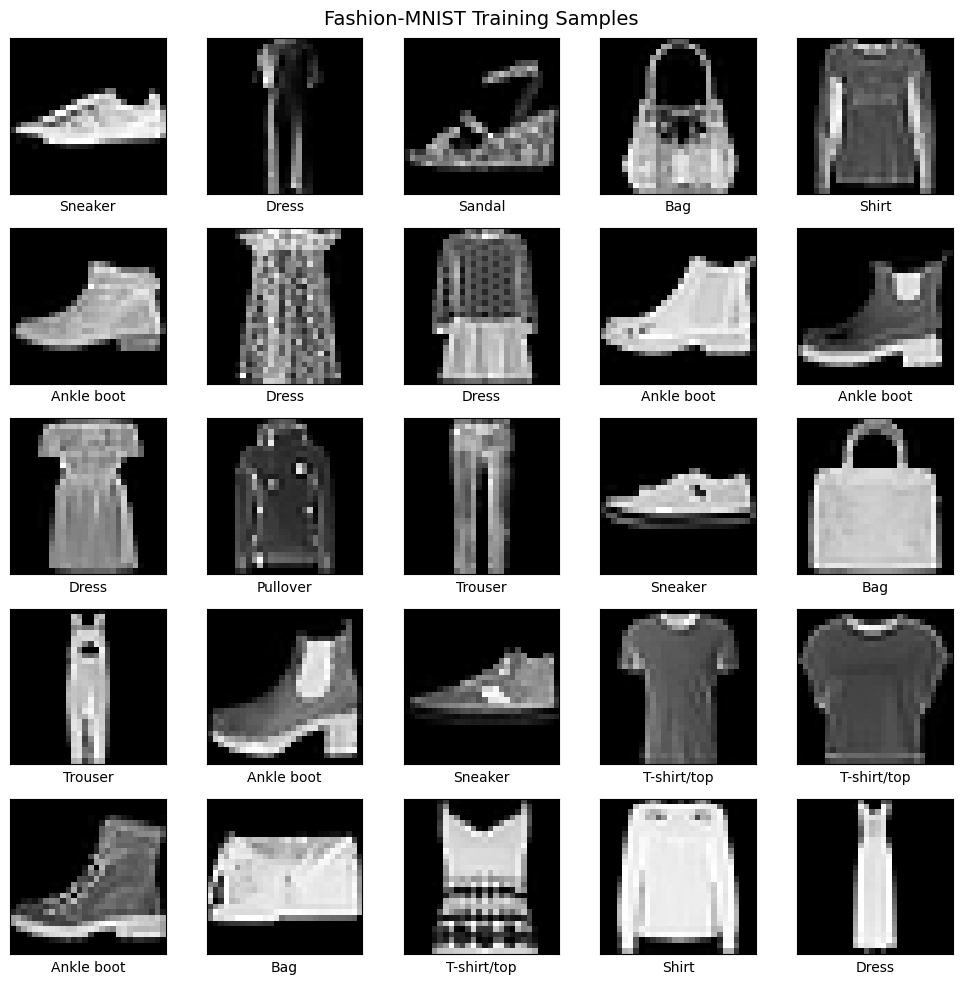

In [ ]:
# data processing

print("=" * 50)
print("1. LOADING FASHION-MNIST")
print("=" * 50)

# Load the data using Keras datasets
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Original Training set: {x_train_full.shape}")
print(f"Original Test set: {x_test.shape}")

print("\n" + "=" * 50)
print("2. CREATING 80-20 TRAIN-VALIDATION SPLIT")
print("=" * 50)

# Split the training data (60,000) into 80% train (48,000) and 20% validation (12,000)
val_size = int(len(x_train_full) * 0.2)  # 12,000 samples
train_size = len(x_train_full) - val_size  # 48,000 samples

# Shuffle indices first (important for random split)
indices = np.random.permutation(len(x_train_full))
x_train_full = x_train_full[indices]
y_train_full = y_train_full[indices]

# Split into train and validation
x_val = x_train_full[:val_size]
y_val = y_train_full[:val_size]
x_train = x_train_full[val_size:]
y_train = y_train_full[val_size:]

print(f"Training:   {x_train.shape} ({train_size:,} samples - 80%)")
print(f"Validation: {x_val.shape} ({val_size:,} samples - 20%)")
print(f"Test:       {x_test.shape} ({len(x_test):,} samples)")

print("\n" + "=" * 50)
print("3. SCALING / NORMALIZATION & RESHAPING")
print("=" * 50)

# Normalize to [0,1]
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add channel dimension (28, 28, 1) for CNNs
x_train = np.expand_dims(x_train, axis=-1)
x_val = np.expand_dims(x_val, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(f"x_train: {x_train.shape}")
print(f"x_val:   {x_val.shape}")
print(f"x_test:  {x_test.shape}")
print(f"Pixel range: [{x_train.min():.3f}, {x_train.max():.3f}]")

# Visualize the img dataset
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.xlabel(class_names[y_train[i]])
plt.suptitle("Fashion-MNIST Training Samples", fontsize=14)
plt.tight_layout()
plt.show()

# Model 1: LeNet-5

Running LeNet-5 (Learning Rate = 0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6865 - loss: 0.8796 - val_accuracy: 0.8190 - val_loss: 0.4782
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8372 - loss: 0.4489 - val_accuracy: 0.8547 - val_loss: 0.3980
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8602 - loss: 0.3811 - val_accuracy: 0.8713 - val_loss: 0.3487
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8748 - loss: 0.3427 - val_accuracy: 0.8808 - val_loss: 0.3282
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8834 - loss: 0.3155 - val_accuracy: 0.8828 - val_loss: 0.3253
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8912 - loss: 0.2952 - val_accuracy: 0.8840 - val_loss: 0.3174
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8972 - loss: 0.2791 - val_accuracy: 0.8876 - val_loss: 0.3105
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9022 - loss: 0.2650 - val_accuracy: 0.

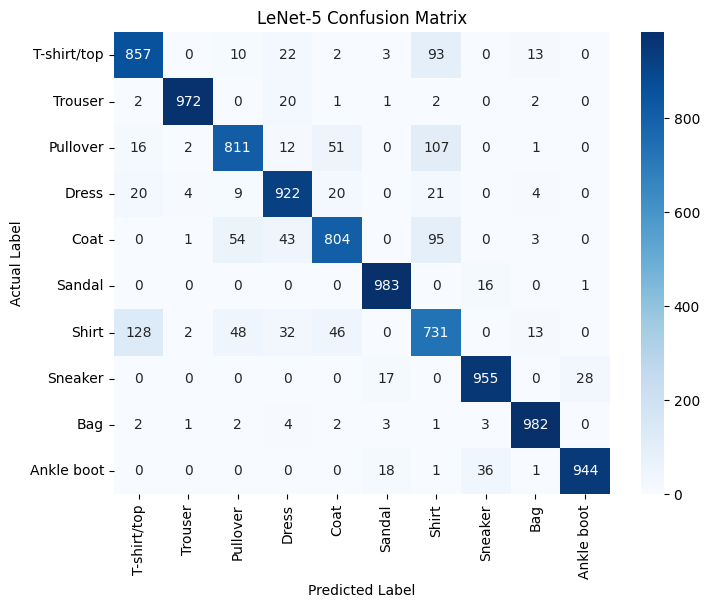

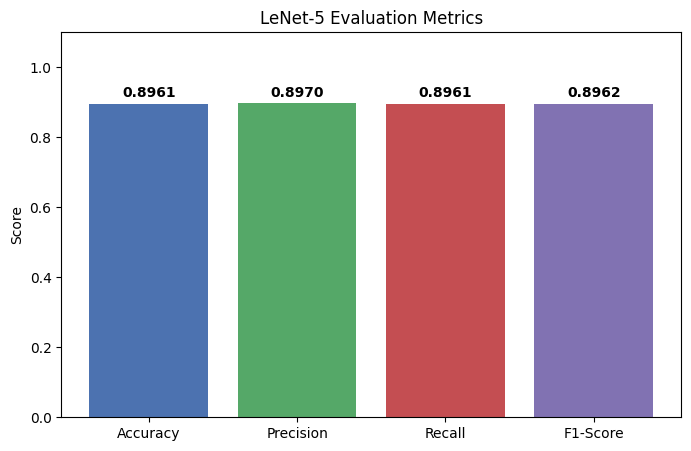

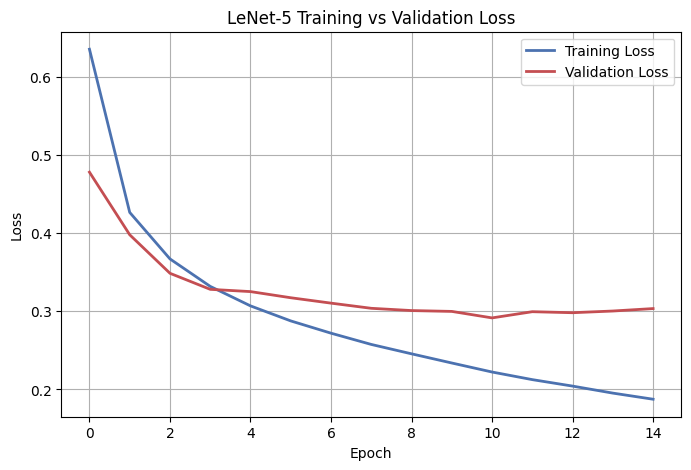

In [ ]:
# Finalized LeNet-5 Model with best LR (0.001)
from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 50)
print("Running LeNet-5 (Learning Rate = 0.001)")
print("=" * 50)

# 1. Model Definition
model_lenet = models.Sequential([
    layers.Conv2D(6, kernel_size=(5, 5), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),
    layers.Conv2D(16, kernel_size=(5, 5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=2),
    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 2. Compile Model
model_lenet.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train Model
early_stopper = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
history_lenet = model_lenet.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopper],
    verbose=1
)

# 4. Evaluation Metrics
y_pred = np.argmax(model_lenet.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

test_loss, test_acc = model_lenet.evaluate(x_test, y_test, verbose=0)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# 5. Output Final Results
print("\n" + "=" * 30)
print("LeNet-5 EVALUATION METRICS")
print("=" * 30)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# 6. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('LeNet-5 Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 7. Plot Evaluation Metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_acc, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('LeNet-5 Evaluation Metrics')
plt.ylabel('Score')
plt.show()

# 8. Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(history_lenet.history['loss'], label='Training Loss', color='#4C72B0', linewidth=2)
plt.plot(history_lenet.history['val_loss'], label='Validation Loss', color='#C44E52', linewidth=2)
plt.title('LeNet-5 Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Model 2: Multi-Layer Perceptron


Running Multi-Layer Perceptron (Learning Rate = 0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7362 - loss: 0.7341 - val_accuracy: 0.8448 - val_loss: 0.4130
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8406 - loss: 0.4336 - val_accuracy: 0.8666 - val_loss: 0.3668
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8589 - loss: 0.3886 - val_accuracy: 0.8721 - val_loss: 0.3526
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8637 - loss: 0.3684 - val_accuracy: 0.8767 - val_loss: 0.3402
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8702 - loss: 0.3524 - val_accuracy: 0.8773 - val_loss: 0.3419
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8748 - loss: 0.3414 - val_accuracy: 0.8801 - val_loss: 0.3270
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8777 - loss: 0.3278 - val_accuracy: 0.8817 - val_loss: 0.3197
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8833 - loss: 0.3150 - val_accuracy: 0.

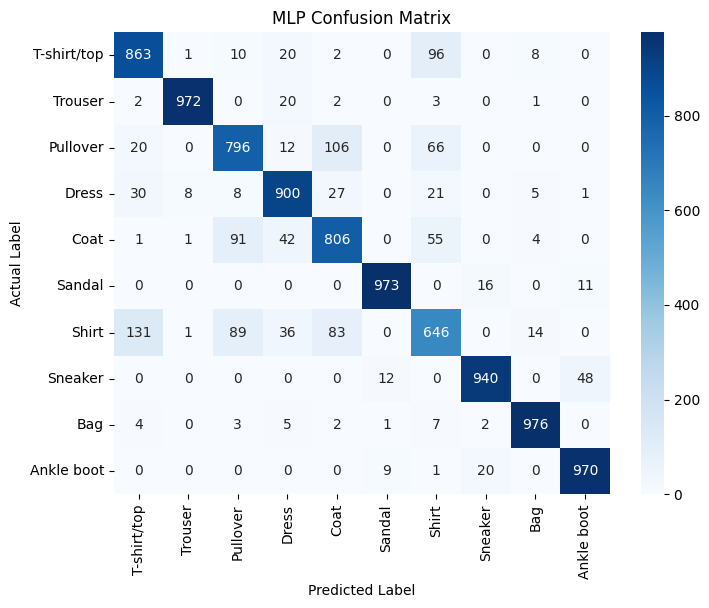

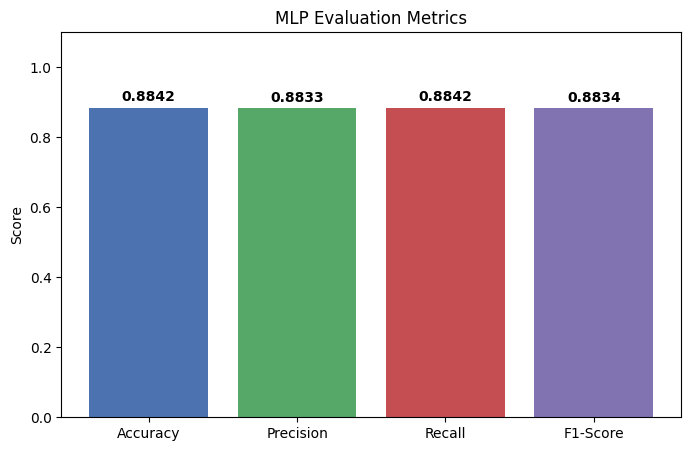

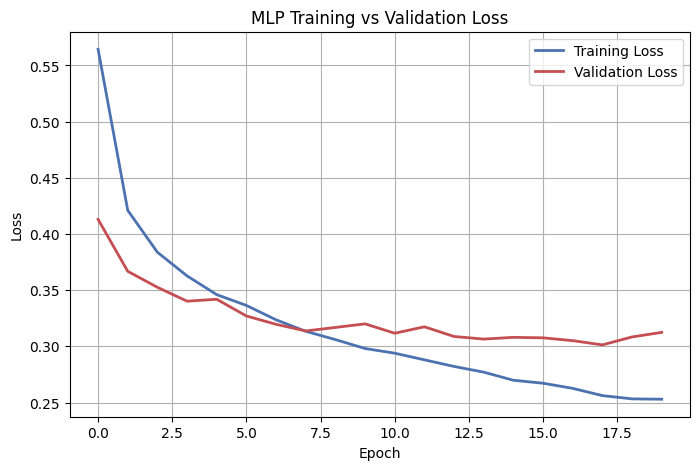

In [ ]:
# Finalized MLP Model with best LR (0.001)
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "=" * 50)
print("Running Multi-Layer Perceptron (Learning Rate = 0.001)")
print("=" * 50)

# 1. Model Definition
model_mlp = models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 2. Compile Model
model_mlp.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train Model
early_stopper = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
history_mlp = model_mlp.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopper],
    verbose=1
)

# 4. Evaluation Metrics
y_pred = np.argmax(model_mlp.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

test_loss, test_acc = model_mlp.evaluate(x_test, y_test, verbose=0)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# 5. Output Final Results
print("\n" + "=" * 30)
print("MLP EVALUATION METRICS")
print("=" * 30)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# 6. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('MLP Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 7. Plot Evaluation Metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_acc, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('MLP Evaluation Metrics')
plt.ylabel('Score')
plt.show()

# 8. Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(history_mlp.history['loss'], label='Training Loss', color='#4C72B0', linewidth=2)
plt.plot(history_mlp.history['val_loss'], label='Validation Loss', color='#C44E52', linewidth=2)
plt.title('MLP Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Model 3: Shallow CNN


Running Shallow CNN (Learning Rate = 0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7178 - loss: 0.7828 - val_accuracy: 0.8698 - val_loss: 0.3532
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8547 - loss: 0.4146 - val_accuracy: 0.8864 - val_loss: 0.3049
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8759 - loss: 0.3541 - val_accuracy: 0.8963 - val_loss: 0.2811
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8796 - loss: 0.3297 - val_accuracy: 0.8998 - val_loss: 0.2687
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8883 - loss: 0.3070 - val_accuracy: 0.9045 - val_loss: 0.2606
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8943 - loss: 0.2919 - val_accuracy: 0.9053 - val_loss: 0.2525
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8983 - loss: 0.2735 - val_accuracy: 0.9090 - val_loss: 0.2458
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9029 - loss: 0.2641 - val_accuracy: 0.

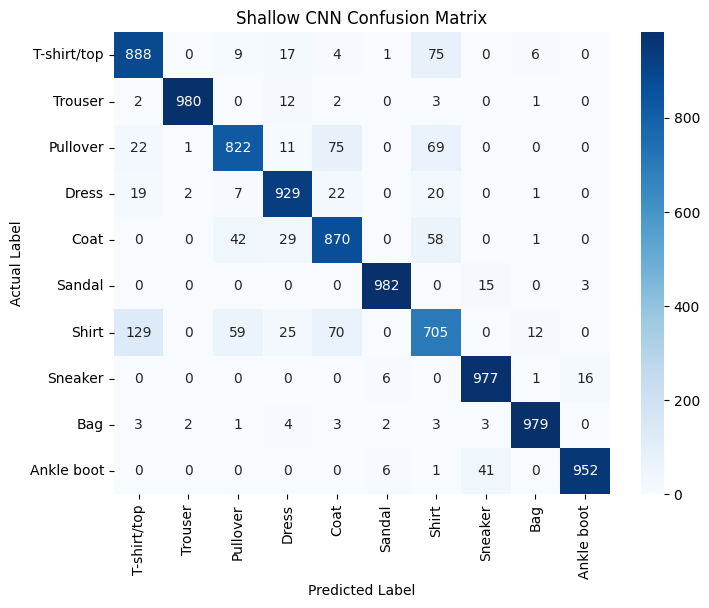

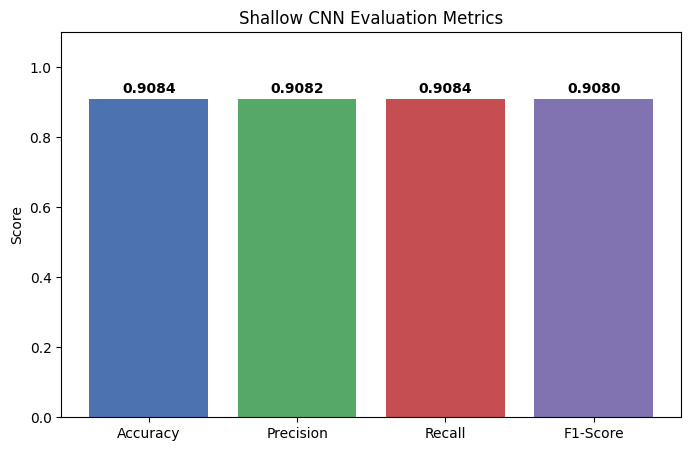

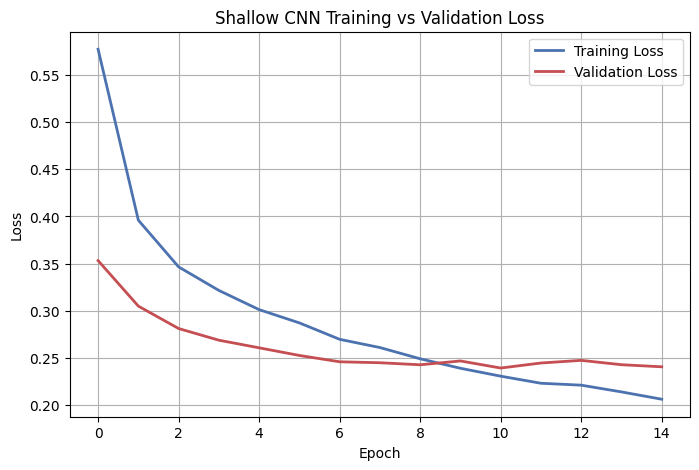

In [ ]:
# Finalized Shallow CNN Model with best LR (0.001)
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "=" * 50)
print("Running Shallow CNN (Learning Rate = 0.001)")
print("=" * 50)

# 1. Model Definition
model_shallow_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 2. Compile Model
model_shallow_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train Model
early_stopper = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
history_shallow_cnn = model_shallow_cnn.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopper],
    verbose=1
)

# 4. Evaluation Metrics
y_pred = np.argmax(model_shallow_cnn.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

test_loss, test_acc = model_shallow_cnn.evaluate(x_test, y_test, verbose=0)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# 5. Output Final Results
print("\n" + "=" * 30)
print("SHALLOW CNN EVALUATION METRICS")
print("=" * 30)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# 6. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Shallow CNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 7. Plot Evaluation Metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_acc, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('Shallow CNN Evaluation Metrics')
plt.ylabel('Score')
plt.show()

# 8. Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(history_shallow_cnn.history['loss'], label='Training Loss', color='#4C72B0', linewidth=2)
plt.plot(history_shallow_cnn.history['val_loss'], label='Validation Loss', color='#C44E52', linewidth=2)
plt.title('Shallow CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Model 4: Deep CNN


Running Deep CNN (Learning Rate = 0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.6130 - loss: 1.0082 - val_accuracy: 0.8403 - val_loss: 0.4306
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8418 - loss: 0.4364 - val_accuracy: 0.8817 - val_loss: 0.3274
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8761 - loss: 0.3495 - val_accuracy: 0.8957 - val_loss: 0.2848
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8871 - loss: 0.3072 - val_accuracy: 0.9043 - val_loss: 0.2589
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8967 - loss: 0.2869 - val_accuracy: 0.9097 - val_loss: 0.2452
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9018 - loss: 0.2638 - val_accuracy: 0.9118 - val_loss: 0.2377
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9098 - loss: 0.2525 - val_accuracy: 0.9122 - val_loss: 0.2380
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9137 - loss: 0.2392 - val_accuracy: 0

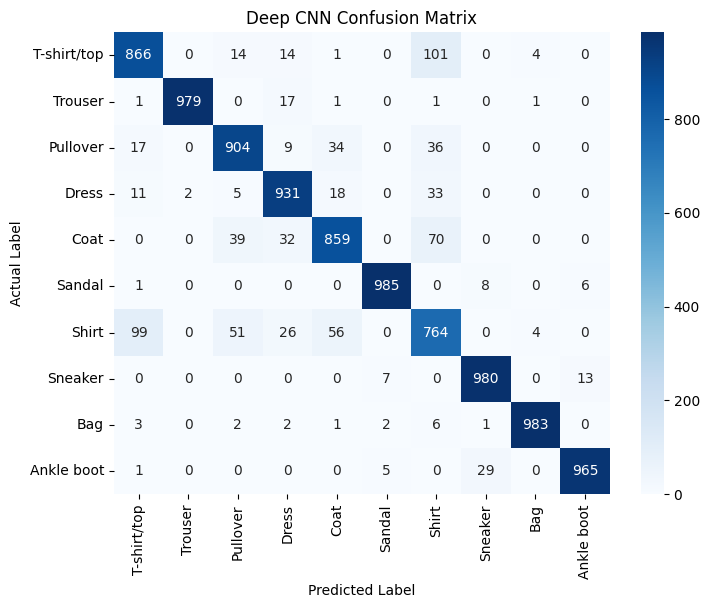

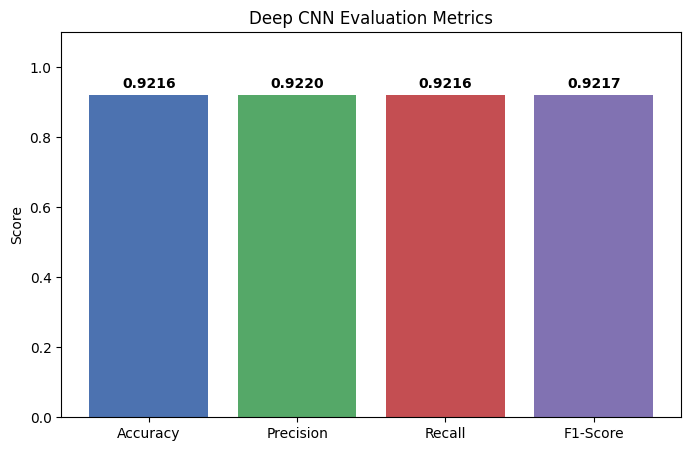

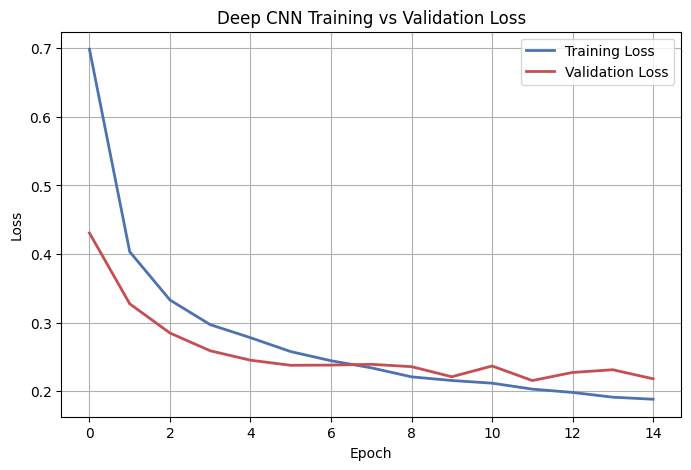

In [ ]:
# Finalized Deep CNN Model with best LR (0.001)
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "=" * 50)
print("Running Deep CNN (Learning Rate = 0.001)")
print("=" * 50)

# 1. Model Definition
model_deep_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 2. Compile Model
model_deep_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train Model
early_stopper = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
history_deep_cnn = model_deep_cnn.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopper],
    verbose=1
)

# 4. Evaluation Metrics
y_pred = np.argmax(model_deep_cnn.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

test_loss, test_acc = model_deep_cnn.evaluate(x_test, y_test, verbose=0)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# 5. Output Final Results
print("\n" + "=" * 30)
print("DEEP CNN EVALUATION METRICS")
print("=" * 30)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# 6. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Deep CNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 7. Plot Evaluation Metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_acc, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('Deep CNN Evaluation Metrics')
plt.ylabel('Score')
plt.show()

# 8. Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(history_deep_cnn.history['loss'], label='Training Loss', color='#4C72B0', linewidth=2)
plt.plot(history_deep_cnn.history['val_loss'], label='Validation Loss', color='#C44E52', linewidth=2)
plt.title('Deep CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Model 5: Custom CNN


Running Custom CNN (Learning Rate = 0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7831 - loss: 0.6608 - val_accuracy: 0.8745 - val_loss: 0.3380
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8848 - loss: 0.3202 - val_accuracy: 0.8948 - val_loss: 0.2871
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9017 - loss: 0.2757 - val_accuracy: 0.9136 - val_loss: 0.2354
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9096 - loss: 0.2509 - val_accuracy: 0.9126 - val_loss: 0.2299
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9143 - loss: 0.2316 - val_accuracy: 0.9239 - val_loss: 0.2068
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9237 - loss: 0.2151 - val_accuracy: 0.9232 - val_loss: 0.2075
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9261 - loss: 0.2005 - val_accuracy: 0.9179 - val_loss: 0.2300
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9308 - loss: 0.1906 - val_accuracy: 

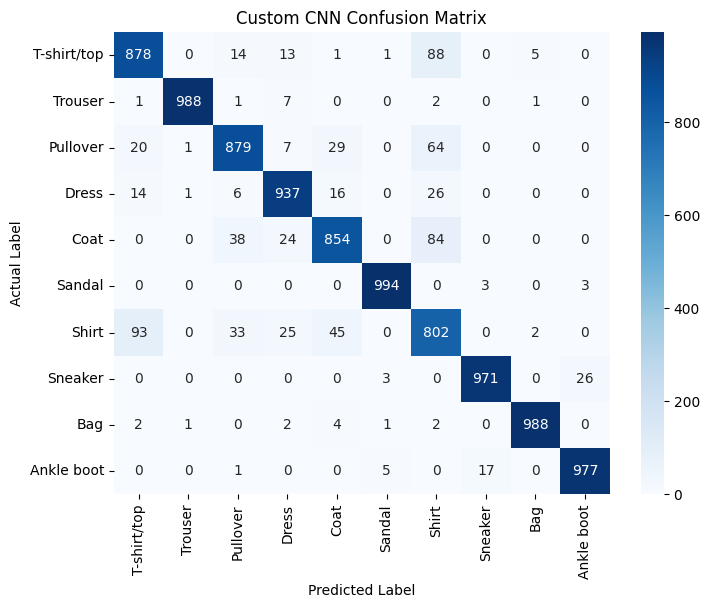

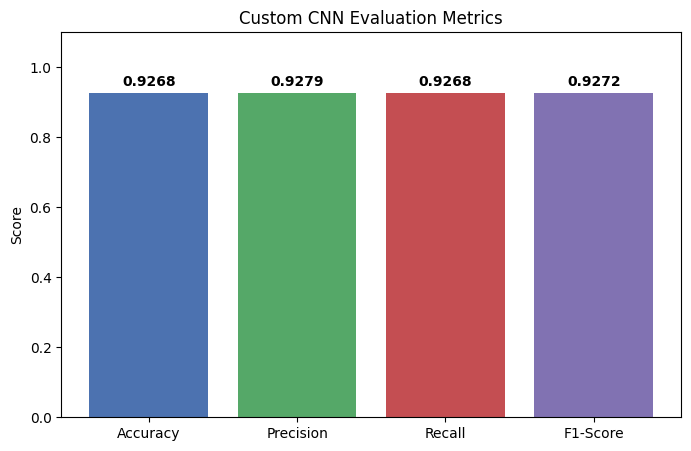

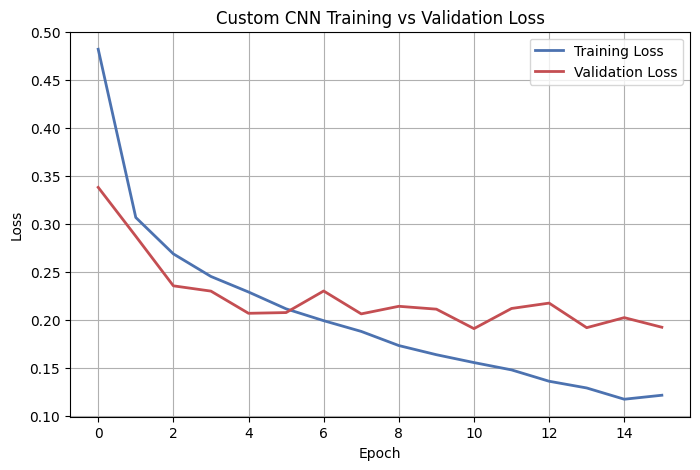

In [ ]:
# Finalized Custom CNN Model with best LR (0.001)
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "=" * 50)
print("Running Custom CNN (Learning Rate = 0.001)")
print("=" * 50)

# 1. Model Definition
model_custom_cnn = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classification Head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 2. Compile Model
model_custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train Model
early_stopper = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_custom_cnn = model_custom_cnn.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopper],
    verbose=1
)

# 4. Evaluation Metrics
y_pred = np.argmax(model_custom_cnn.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

test_loss, test_acc = model_custom_cnn.evaluate(x_test, y_test, verbose=0)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# 5. Output Final Results
print("\n" + "=" * 30)
print("CUSTOM CNN EVALUATION METRICS")
print("=" * 30)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# 6. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Custom CNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 7. Plot Evaluation Metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_acc, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.title('Custom CNN Evaluation Metrics')
plt.ylabel('Score')
plt.show()

# 8. Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(history_custom_cnn.history['loss'], label='Training Loss', color='#4C72B0', linewidth=2)
plt.plot(history_custom_cnn.history['val_loss'], label='Validation Loss', color='#C44E52', linewidth=2)
plt.title('Custom CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()